# Cross Check and Descriptive Statistics

The code in this file directly use the outputs of "02_build_corpus.py" (does not re-run collection or cleaning). Two checks run before the descriptive summary:
1. **Boilerplate spot-check** — does cleaning perform equally well across institutions, or does residual junk inflate word counts for one of them?
2. **Threshold sensitivity** — how does corpus size respond to the MIN_DOC_WORDS / MIN_DENSITY / MIN_AI_MENTIONS cutoffs in "build_corpus.py"?

In [1]:
# This chunk of code is the same as my teammate
import sys
from pathlib import Path

import pandas as pd
import re

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))

import build_corpus  # noqa: E402
import collect        # noqa: E402

CORPUS = ROOT / "data" / "corpus"
RAW = ROOT / "data" / "raw"

docs = pd.read_parquet(CORPUS / "documents.parquet")
paras = pd.read_parquet(CORPUS / "paragraphs.parquet")
exclusions = pd.read_csv(CORPUS / "exclusions.csv")

print(f"documents: {len(docs)} | paragraphs: {len(paras)} | excluded: {len(exclusions)}")


documents: 134 | paragraphs: 27486 | excluded: 12


In [2]:
# This chunk reads my teammate's output of the pipeline
docs = pd.read_parquet(CORPUS / "documents.parquet")
paras = pd.read_parquet(CORPUS / "paragraphs.parquet")
exclusions = pd.read_csv(CORPUS / "exclusions.csv")

print(f"documents: {len(docs)} | paragraphs: {len(paras)} | excluded: {len(exclusions)}")
print("\ndocuments.parquet columns:", docs.columns.tolist())
print("paragraphs.parquet columns:", paras.columns.tolist())
print(f"\nraw/ folder exists: {RAW.exists()}")

documents: 134 | paragraphs: 27486 | excluded: 12

documents.parquet columns: ['doc_id', 'work', 'institution', 'doc_type', 'genre', 'type_raw', 'date', 'year', 'title', 'mtype', 'fmt', 'n_words', 'n_paragraphs', 'ai_mentions', 'ai_density']
paragraphs.parquet columns: ['doc_id', 'para_idx', 'institution', 'doc_type', 'genre', 'year', 'n_words', 'ai_mentions', 'text']

raw/ folder exists: False


## 1. Boilerplate cleaning spot-check

"BOILERPLATE" in "build_corpus.py" was written primarily against Council routing headers and Commission publication footers. It is not obvious the same patterns catch everything in Parliament documents (resolutions, amendment lists), which carry their own recurring markers — e.g. translation tags ("Or. en"), amendment/justification headers, PE document codes.

Here we check:

(a) check a few before/after examples per institution,

(b) search all documents for this Parliament-style junk to see how much is still left after cleaning.

**(A) Before/ After Examples per Institution**

In [6]:
def reconstructed_clean_text(doc_id: str) -> str:
    sub = paras[paras.doc_id == doc_id].sort_values("para_idx")
    return "\n\n".join(sub["text"])

for inst in ["Commission", "Parliament", "Council"]:
    sample_ids = docs[docs.institution == inst]["doc_id"].sample(
        n=min(2, (docs.institution == inst).sum()), random_state=0
    )
    for doc_id in sample_ids:
        clean_text = reconstructed_clean_text(doc_id)
        print(f"\n=== [{inst}] {doc_id} ===")
        print(f"words after cleaning (reconstructed): {len(clean_text.split())}")
        print("--- first 400 chars ---")
        print(clean_text[:400] if clean_text else "(no paragraphs found — check doc_id)")


=== [Commission] b397c30e-6a63-11f1-ae88-01aa75ed71a1 ===
words after cleaning (reconstructed): 14902
--- first 400 chars ---
COMMUNICATION FROM THE COMMISSION TO THE EUROPEAN PARLIAMENT, THE COUNCIL, THE EUROPEAN ECONOMIC AND SOCIAL COMMITTEE AND THE COMMITTEE OF THE REGIONS

State of the Digital Decade 2026: Closing structural gaps and mobilising investments for 2030 and beyond

{SWD(2026) 154 final} - {SWD(2026) 155 final} - {SWD(2026) 156 final} - {SWD(2026) 157 final}

In 2026, the EU is facing a combination of long

=== [Commission] baebce15-1ef5-11ed-8fa0-01aa75ed71a1 ===
words after cleaning (reconstructed): 5170
--- first 400 chars ---
authorising the opening of negotiations on behalf of the European Union for a Council of Europe convention on artificial intelligence, human rights, democracy and the rule of law

Artificial intelligence (AI) offers great opportunities for society, the environment and the economy. At the same time, depending on the circumstances regarding its s

**(B) Candidate Residual Pattern not currently in Boilerplate**

The search pattern below is written by thinking about what Parliament documents specifically look like. It aims to test something the original rules might have missed, not to double-check something they already cover.

In [4]:
CANDIDATE_RESIDUAL = {
    "translation_marker": re.compile(r"(?im)^\s*Or\.\s*[a-z]{2}\s*$"),
    "amendment_header": re.compile(r"(?im)^\s*Amendment\s+\d+\s*$"),
    "justification_header": re.compile(r"(?im)^\s*Justification\s*$"),
    "pe_doc_code": re.compile(r"PE\d{3,4}\.\d{3}v\d{2}-\d{2}"),
    "page_of_pe": re.compile(r"(?im)^\s*\d+/\d+\s+PE\d{3,4}\.\d{3}\s*$"),
}

# Reconstruct clean text per document from paragraphs
docs_clean_text = (paras.sort_values(["doc_id", "para_idx"])
                        .groupby("doc_id")["text"]
                        .apply(lambda s: "\n\n".join(s)))

rows = []
for doc_id, institution in docs[["doc_id", "institution"]].itertuples(index=False):
    text = docs_clean_text.get(doc_id, "")
    for label, pattern in CANDIDATE_RESIDUAL.items():
        n_hits = len(pattern.findall(text))
        if n_hits:
            rows.append({"institution": institution, "doc_id": doc_id,
                        "pattern": label, "hits": n_hits})

residual = pd.DataFrame(rows)
if len(residual):
    print("Residual boilerplate hits by institution and pattern:")
    print(residual.pivot_table(index="institution", columns="pattern",
                               values="hits", aggfunc="sum", fill_value=0))
else:
    print("No hits for the candidate patterns — current BOILERPLATE list looks sufficient.")

No hits for the candidate patterns — current BOILERPLATE list looks sufficient.


#### Limitation of the BIOLERPLATE spot check
We only checked the cleaned documents rather than comparing the raw and the cleaned one. So we can only see what the text looks like *after* cleaning, not what cleaning actually removed. 

This spot-check gives us reasonable, but not complete confidence that cleaning worked evenly across institutions

# 2. Sensitivity Test


The aim of sensitivity test is to examine whether the threshold number in build_corpus.py (200, 0.5, 2) is reasonable, and whether they can be justified.

In [8]:
# The retrieval log wants to explore within the in-scope documents (before applying the threshold code), how many documents are downloaded and retreivable
retrieval_log = pd.read_csv(CORPUS / "retrieval_log.csv")
print(retrieval_log["status"].value_counts())
print("\nby institution (need to merge with docs/works metadata to get institution):")
works_meta = pd.read_csv(ROOT / "data" / "inventory" / "works_union.csv")
works_meta["doc_id"] = works_meta["work"].str.split("/").str[-1]
merged = retrieval_log.merge(works_meta[["doc_id", "institution"]], on="doc_id", how="left")
print(merged.groupby(["institution", "status"]).size().unstack(fill_value=0))

status
cached    94
ok        43
Name: count, dtype: int64

by institution (need to merge with docs/works metadata to get institution):
status       cached  ok
institution            
Commission       73   5
Council          18   8
Parliament        3  30


It shows that for the in-scope documents, 137 documents entered the data/raw, and the result is imbalanced across the institutions. 

In [9]:
cols = ["doc_id", "institution", "n_words", "ai_mentions", "ai_density"]
population = pd.concat([docs[cols], exclusions[cols]], ignore_index=True)
print(f"population for sensitivity check: {len(population)} documents "
      f"(= {len(docs)} kept + {len(exclusions)} excluded)")
print(f"NOTE: this population reflects only documents whose full text was "
      f"successfully retrieved (see retrieval coverage check above). "
      f"Of in-scope documents from Week 2, only {len(population)} "
      f"({100*len(population)/186:.0f}%) reached this stage — the threshold "
      f"sensitivity below is conditional on retrieval, not on the full scope.")

CURRENT = dict(min_doc_words=build_corpus.MIN_DOC_WORDS,
              min_density=build_corpus.MIN_DENSITY,
              min_ai_mentions=build_corpus.MIN_AI_MENTIONS)
print("current thresholds:", CURRENT)

population for sensitivity check: 146 documents (= 134 kept + 12 excluded)
NOTE: this population reflects only documents whose full text was successfully retrieved (see retrieval coverage check above). Of in-scope documents from Week 2, only 146 (78%) reached this stage — the threshold sensitivity below is conditional on retrieval, not on the full scope.
current thresholds: {'min_doc_words': 200, 'min_density': 0.5, 'min_ai_mentions': 2}


In [11]:
def apply_thresholds(pop: pd.DataFrame, min_doc_words: int,
                     min_density: float, min_ai_mentions: int) -> pd.DataFrame:
    """Re-apply build_corpus.py's exclusion logic at alternative thresholds."""
    too_short = pop["n_words"] < min_doc_words
    peripheral = (~too_short) & (
        (pop["ai_density"] < min_density) | (pop["ai_mentions"] < min_ai_mentions)
    )
    return pop[~too_short & ~peripheral]

#### MIN_DENSITY CHECK

In [12]:
density_grid = [0.0, 0.3, 0.5, 0.75, 1.0, 1.5]
rows = []
for d in density_grid:
    kept = apply_thresholds(population, CURRENT["min_doc_words"], d, CURRENT["min_ai_mentions"])
    row = {"MIN_DENSITY": d, "total": len(kept)}
    row.update(kept.groupby("institution").size().to_dict())
    rows.append(row)
density_sensitivity = pd.DataFrame(rows).set_index("MIN_DENSITY")
print(density_sensitivity)

             total  Commission  Council  Parliament
MIN_DENSITY                                        
0.00           135          76       28          31
0.30           135          76       28          31
0.50           134          75       28          31
0.75           133          75       28          30
1.00           129          73       28          28
1.50           125          71       27          27


We tested MIN_DENSITY at 0, 0.3, 0.5, 0.75, 1.0, and 1.5. The corpus barely changes between 0 and 0.5 (135 → 134 documents), and the drop is almost entirely from Commission. Council and Parliament do not lose any documents at this level. Real filtering only starts around 1.0–1.5. This tells us our chosen value, 0.5, is a light-touch threshold: it removes almost nothing right now, but we keep it because it protects borderline-relevant documents rather than risking cutting real ones.

#### MIN_DOC_WORDS CHECK

In [13]:
words_grid = [0, 100, 150, 200, 300, 500]
rows = []
for w in words_grid:
    kept = apply_thresholds(population, w, CURRENT["min_density"], CURRENT["min_ai_mentions"])
    row = {"MIN_DOC_WORDS": w, "total": len(kept)}
    row.update(kept.groupby("institution").size().to_dict())
    rows.append(row)
words_sensitivity = pd.DataFrame(rows).set_index("MIN_DOC_WORDS")
print(words_sensitivity)

               total  Commission  Council  Parliament
MIN_DOC_WORDS                                        
0                137          75       31          31
100              136          75       30          31
150              135          75       29          31
200              134          75       28          31
300              129          75       24          30
500              128          74       24          30


We tested this at 0, 100, 150, 200, 300, and 500 words. Commission and Parliament stay almost flat across all these values. Council is different: it drops steadily, from 31 documents at 0 words to only 24 at 500 words, a 23% loss. This matches what we already noted in Week 2 — Council documents tend to be shorter and more procedural. We chose 200 words instead of going higher (like 300 or 500) because raising the bar further would shrink the Council subset even more, making the imbalance between institutions worse without removing many documents from the other two institutions.

The two thresholds affect the institutions differently. MIN_DENSITY mostly filters Commission/Parliament documents that barely mention AI.MIN_DOC_WORDS mostly filters short Council documents. Together with the retrieval gap for Parliament, this means our current corpus is shaped as much by data availability and document length as by our actual relevance criteria. We see this as an honest limitation to report

# Descriptive Statistics

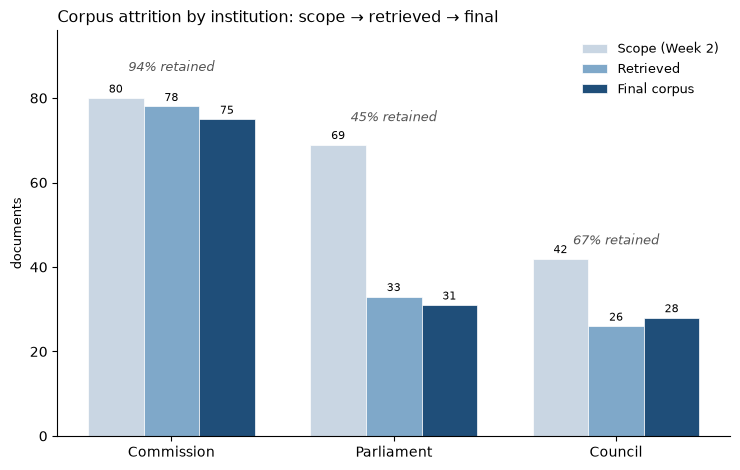

In [21]:
import matplotlib.pyplot as plt
import numpy as np

INST = ["Commission", "Parliament", "Council"]
STAGE_COLORS = ["#c9d6e3", "#7fa8c9", "#1f4e79"]  # 浅→深,呼应"逐步流失"的叙事

scope_counts = works_meta[works_meta["scope"] == "in"].groupby("institution").size()
retrieved_counts = merged[merged["status"].isin(["ok", "cached"])].groupby("institution").size()
final_counts = docs.groupby("institution").size()

funnel = pd.DataFrame({
    "Scope (Week 2)": scope_counts,
    "Retrieved": retrieved_counts,
    "Final corpus": final_counts,
}).reindex(INST)

retention_pct = (funnel["Final corpus"] / funnel["Scope (Week 2)"] * 100).round(0)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = np.arange(len(INST))
width = 0.25

for i, stage in enumerate(funnel.columns):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, funnel[stage], width, label=stage,
                  color=STAGE_COLORS[i], edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fontsize=8, padding=2)

# 在每组柱子上方标注最终留存率,直接点出Parliament的问题
for i, inst in enumerate(INST):
    ax.text(x[i], funnel.loc[inst].max() * 1.08, f"{retention_pct[inst]:.0f}% retained",
           ha="center", fontsize=9, color="#555", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(INST, fontsize=10)
ax.set_ylabel("documents", fontsize=9.5)
ax.set_title("Corpus attrition by institution: scope → retrieved → final",
            fontsize=11.5, loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, funnel.values.max() * 1.2)  # 给顶部标注留空间

fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "week3_corpus_attrition.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# Sanity check: does the funnel's "Retrieved" count match "Final corpus"?
# Council showed Retrieved=26 < Final=28, which looked like an impossible increase. Investigated and found two explanable causes:
retrieved_ids = set(merged[merged["institution"] == "Council"]["doc_id"])
final_ids = set(docs[docs["institution"] == "Council"]["doc_id"])

# (1) 6 documents in retrieved-but-not-final are legitimately excluded by
#     build_corpus.py's thresholds (confirmed present in exclusions.csv, mostly "under 200 words after cleaning").
in_retrieved_not_final = retrieved_ids - final_ids
check_a = exclusions[exclusions["doc_id"].isin(in_retrieved_not_final)]
assert len(check_a) == len(in_retrieved_not_final), "unexplained retrieval/final mismatch"

# (2) 8 documents in final-but-not-retrieved were fetched via the Council  register fallback (collect_council), which was not reflected in the committed retrieval_log.csv (a stale/incomplete log, not a data problem — all 8 have mtype=None, consistent with the URI-only retrieval path).
in_final_not_retrieved = final_ids - retrieved_ids
check_b = docs[docs["doc_id"].isin(in_final_not_retrieved)]
assert (check_b["mtype"].isna()).all(), "unexplained final-only documents with a known mtype"

print("Funnel discrepancy fully explained: no missing or duplicated documents.")
print(f"  - {len(check_a)} docs excluded by thresholds (in exclusions.csv)")
print(f"  - {len(check_b)} docs retrieved via Council-register fallback, "
      f"not reflected in retrieval_log.csv (log file is stale, not a data issue)")

Funnel discrepancy fully explained: no missing or duplicated documents.
  - 6 docs excluded by thresholds (in exclusions.csv)
  - 8 docs retrieved via Council-register fallback, not reflected in retrieval_log.csv (log file is stale, not a data issue)


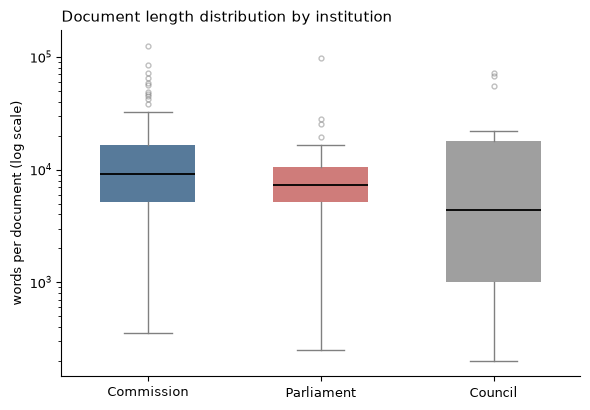

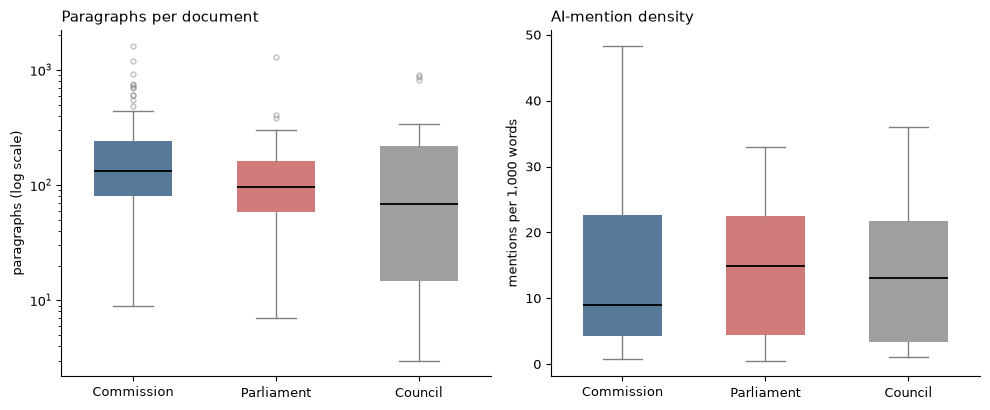

In [ ]:
INST = ["Commission", "Parliament", "Council"]
COLORS = {"Commission": "#1f4e79", "Parliament": "#c0504d", "Council": "#7f7f7f"}

def clean_boxplot(ax, data_by_inst, title, ylabel, log_scale=False):
    bp = ax.boxplot(
        [data_by_inst[inst] for inst in INST],
        tick_labels=INST,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="black", linewidth=1.3),
        flierprops=dict(marker="o", markersize=3.5, markerfacecolor="none",
                        markeredgecolor="grey", alpha=0.5),
        whiskerprops=dict(color="grey"),
        capprops=dict(color="grey"),
    )
    for patch, inst in zip(bp["boxes"], INST):
        patch.set_facecolor(COLORS[inst])
        patch.set_alpha(0.75)
        patch.set_edgecolor("none")
    if log_scale:
        ax.set_yscale("log")
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_ylabel(ylabel, fontsize=9.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)


# Figure 1: document length (log scale — the distribution is heavily right-skewed)
fig, ax = plt.subplots(figsize=(6, 4.2))
data = {inst: docs.loc[docs.institution == inst, "n_words"] for inst in INST}
clean_boxplot(ax, data, "Document length distribution by institution",
             "words per document (log scale)", log_scale=True)
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "week3_doc_length.png", dpi=200, bbox_inches="tight")
plt.show()


# Figure 2: paragraphs per document + AI-mention density, side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

data_para = {inst: docs.loc[docs.institution == inst, "n_paragraphs"] for inst in INST}
clean_boxplot(axes[0], data_para, "Paragraphs per document",
             "paragraphs (log scale)", log_scale=True)

data_density = {inst: docs.loc[docs.institution == inst, "ai_density"] for inst in INST}
clean_boxplot(axes[1], data_density, "AI-mention density",
             "mentions per 1,000 words")

fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "week3_paragraphs_density.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
# Save Figures
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)  

fig.savefig(FIG_DIR / "figure2_corpus_attrition_week3.png", dpi=200, bbox_inches="tight")

fig.savefig(FIG_DIR / "figure3_doc_length_week3.png", dpi=200, bbox_inches="tight")

fig.savefig(FIG_DIR / "figure4_paragraphs_density_week3.png", dpi=200, bbox_inches="tight")